# Task 1: Distance Estimation from Phase Measurements

NOTE: The important information regarding this lab is in Lab3_RFID.pdf.

In this task, you will work on the data in ‘./Lab_Data/lab3_task1.txt’. The setting of the data collection is as follows. We move the RFID tag in a straight line away from the RFID reader and collect phase measurements. We move the RFID tag away from the RFID reader by a distance d and collect phase measurements at each position. 

You are required to compute the phase change at different positions and use that to estimate the distance d as well as the total distance moved by the tag. 
Plot the phase variation vs Time as well as the distance variation vs time. 

In [ ]:
## TODO: Implement these functions
def get_phase_change(pha):

    pha_rad = np.deg2rad(pha)
    
    # Unwrap phase so that jumps at ±π disappear
    pha_unwrapped = np.unwrap(pha_rad, period=np.pi)

    # Compute phase difference between consecutive samples
    dpha = np.diff(pha_unwrapped)

    # Pad with 0 to keep same length as input
    dpha = np.insert(dpha, 0, 0)
    
    return dpha

def get_dist_change(dpha, wavelength = 3e8 / 902750e3):
    # Distance change from phase change: Δd = (λ / 4π) * Δφ
    ddist = (wavelength / (4 * np.pi)) * dpha
    
    return ddist

0.21185267238991937


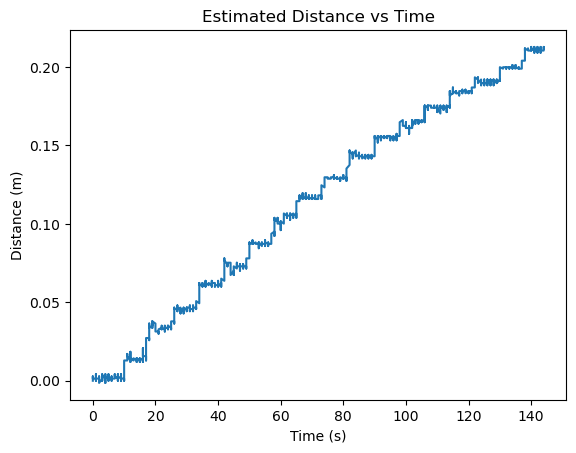

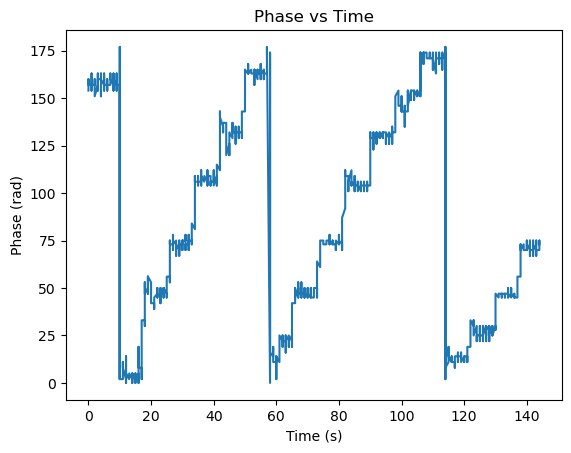

In [ ]:
from utils import read_data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## TODO: Insert data file path here
file = 'Lab_Data/lab3_task1.txt'

# Read data
channel_log = read_data(file)

# Extract and process data
pha = channel_log['Phase'].astype(float).values
freq = channel_log['Frequency'].iloc[0].astype(float) * 1e3
time = ((channel_log['hour'] * 60 + channel_log['minute']) * 60 + channel_log['second']).astype(float).values
time = time - time[0]
c = 3e8

## TODO: Your implementation from here on
# Compute phase change and distance change
dpha = get_phase_change(pha)
ddist = get_dist_change(dpha, wavelength= c / freq)

# Cumulative distance
dist = np.cumsum(ddist)
print(dist[-1])

# Plotting Distance vs Time
plt.figure()
plt.plot(time, dist)
plt.xlabel("Time (s)")
plt.ylabel("Distance (m)")
plt.title("Estimated Distance vs Time")


# Plotting Phase vs Time
plt.figure()
plt.plot(time, pha)
plt.xlabel("Time (s)")
plt.ylabel("Phase (rad)")
plt.title("Phase vs Time")

plt.show()